In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
tsla = pd.read_csv("../data/processed/TSLA_processed.csv")

tsla["Date"] = pd.to_datetime(tsla["Date"])

tsla.set_index("Date", inplace=True)

tsla = tsla[["Close"]]

tsla.head()

,Close
Date,
2015-01-02,14.620667
2015-01-05,14.006000
2015-01-06,14.085333
2015-01-07,14.063333
2015-01-08,14.041333


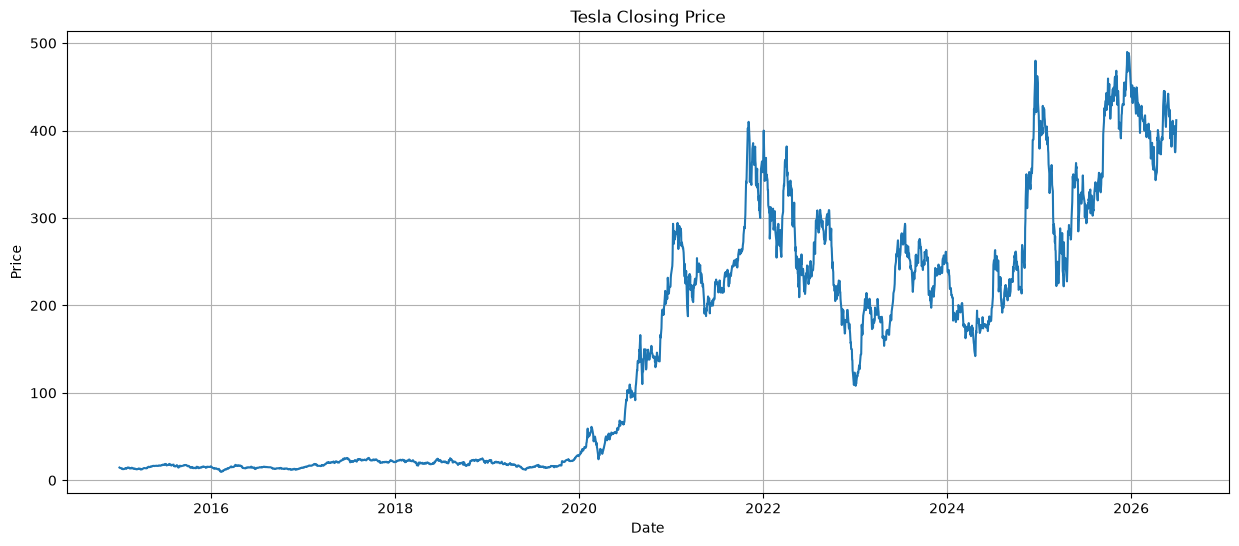

In [3]:
plt.figure(figsize=(15,6))

plt.plot(tsla)

plt.title("Tesla Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.grid(True)

plt.show()

In [4]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(tsla)

scaled_data[:5]

array([[0.01049895],
       [0.0092192 ],
       [0.00938437],
       [0.00933857],
       [0.00929276]])

In [5]:
sequence_length = 60

X = []

y = []

for i in range(sequence_length, len(scaled_data)):

    X.append(scaled_data[i-sequence_length:i])

    y.append(scaled_data[i])

X = np.array(X)

y = np.array(y)

print(X.shape)

print(y.shape)

(2828, 60, 1)
(2828, 1)


In [6]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]

X_test = X[train_size:]

y_train = y[:train_size]

y_test = y[train_size:]

print(X_train.shape)

print(X_test.shape)

(2262, 60, 1)
(566, 60, 1)


In [7]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(64)
)

model.add(Dropout(0.2))

model.add(Dense(32))

model.add(Dense(1))

In [8]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [11]:
history = model.fit(

    X_train,

    y_train,

    validation_data=(X_test,y_test),

    epochs=30,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1

)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - loss: 0.0082 - val_loss: 0.0026
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 0.0013 - val_loss: 0.0021
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - loss: 0.0012 - val_loss: 0.0056
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0011 - val_loss: 0.0034
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 9.4638e-04 - val_loss: 0.0029
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 9.5741e-04 - val_loss: 0.0025


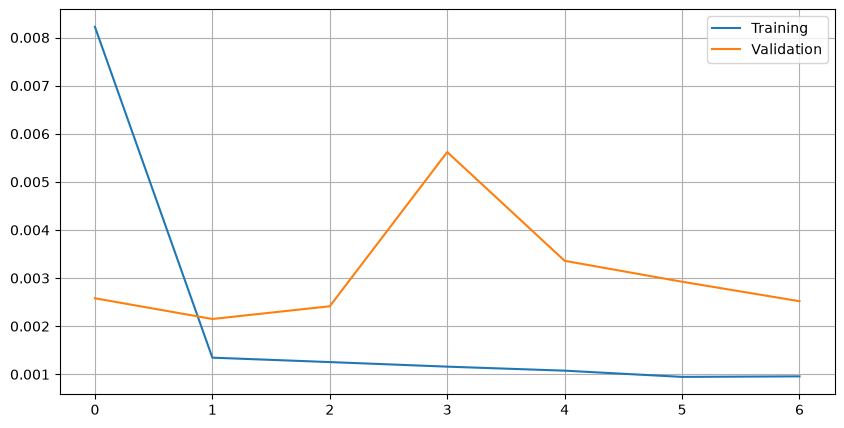

In [12]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Training","Validation"])

plt.grid(True)

plt.show()

In [13]:
predictions = model.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step


In [14]:
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y_test)

In [15]:
results = pd.DataFrame({

    "Actual":actual.flatten(),

    "Predicted":predictions.flatten()

})

results.head()

,Actual,Predicted
0,177.669998,179.728104
1,179.830002,179.815292
2,175.789993,180.335999
3,175.220001,180.899460
4,166.630005,181.433075


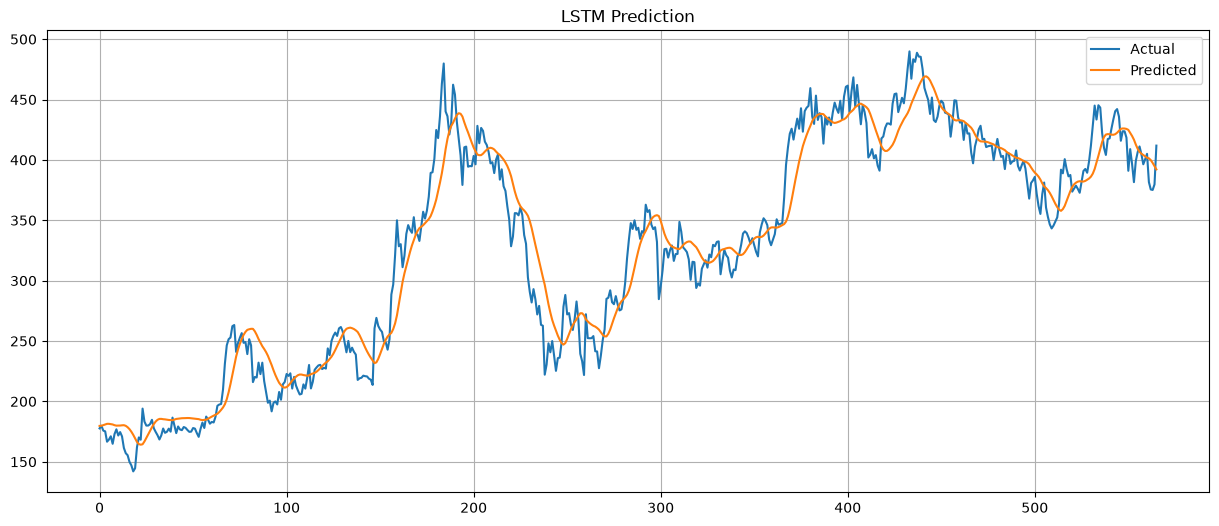

In [16]:
plt.figure(figsize=(15,6))

plt.plot(results["Actual"])

plt.plot(results["Predicted"])

plt.legend(["Actual","Predicted"])

plt.title("LSTM Prediction")

plt.grid(True)

plt.show()

In [17]:
mae = mean_absolute_error(

    actual,

    predictions

)

rmse = np.sqrt(

    mean_squared_error(

        actual,

        predictions

    )

)

mape = mean_absolute_percentage_error(

    actual,

    predictions

)

print("MAE :",mae)

print("RMSE:",rmse)

print("MAPE:",mape)

MAE : 16.860409092987386
RMSE: 22.269628409867057
MAPE: 0.05541006794178475


In [18]:
future_input = scaled_data[-60:]

future_input = future_input.reshape(1,60,1)

future_predictions = []

for i in range(30):

    pred = model.predict(future_input, verbose=0)

    future_predictions.append(pred[0,0])

    future_input = np.append(
        future_input[:,1:,:],
        [[[pred[0,0]]]],
        axis=1
    )

In [19]:
future_predictions = scaler.inverse_transform(

    np.array(future_predictions).reshape(-1,1)

)

future_predictions

array([[391.5139 ],
       [391.0376 ],
       [390.74533],
       [390.57535],
       [390.48758],
       [390.45505],
       [390.46   ],
       [390.49054],
       [390.53876],
       [390.59952],
       [390.6689 ],
       [390.74472],
       [390.8251 ],
       [390.90875],
       [390.99475],
       [391.0823 ],
       [391.17072],
       [391.25967],
       [391.34888],
       [391.43787],
       [391.52646],
       [391.61447],
       [391.70175],
       [391.78802],
       [391.87326],
       [391.95746],
       [392.04047],
       [392.1223 ],
       [392.20297],
       [392.28232]], dtype=float32)

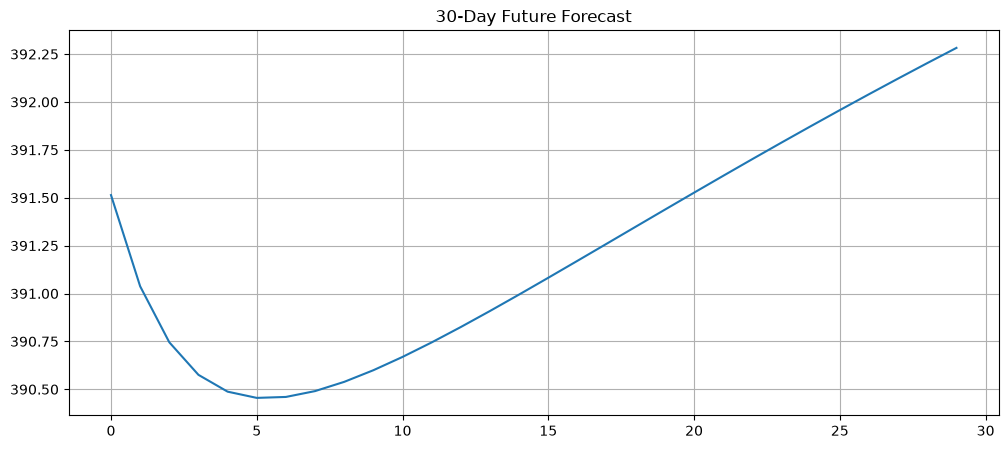

In [20]:
plt.figure(figsize=(12,5))

plt.plot(future_predictions)

plt.title("30-Day Future Forecast")

plt.grid(True)

plt.show()

In [21]:
os.makedirs("../models", exist_ok=True)

model.save("../models/lstm_model.keras")

print("Model Saved")

Model Saved


In [22]:
results.to_csv("../reports/lstm_predictions.csv", index=False)

print("Prediction file saved")

Prediction file saved


In [23]:
comparison = pd.DataFrame({

    "Metric":["MAE","RMSE","MAPE"],

    "ARIMA":[
        "Use your Notebook 3 results",
        "Use your Notebook 3 results",
        "Use your Notebook 3 results"
    ],

    "LSTM":[
        mae,
        rmse,
        mape
    ]

})

comparison

,Metric,ARIMA,LSTM
0,MAE,Use your Notebook 3 results,16.860409
1,RMSE,Use your Notebook 3 results,22.269628
2,MAPE,Use your Notebook 3 results,0.055410


Conclusion

• The LSTM model captures nonlinear patterns in Tesla's stock prices.
• Compare the MAE, RMSE, and MAPE values from the ARIMA and LSTM models.
• The model with the lower error metrics is considered the better forecasting model for this dataset.